# Multiple Inputs Graph

## **Objective**:

1. Define a more complex `AgentState`.
2. Create a processing node that performs operations in **list data**.
3. Set up a `LangGraph` that processes and outputs computed results.
4. Invoke the graph with structured inputs and retrieve outputs.

In [14]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [15]:
class AgentState(TypedDict):
    values: List[int]
    name: str 
    result: str

In [16]:
def process_values(state: AgentState) -> AgentState:
    """
    This function handles multiple different input
    """
    print(state)
    state["result"] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"
    print(state)
    return state 

In [17]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()


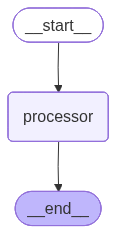

In [18]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve"})

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}


In [20]:
print(answers)

{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}


In [21]:
print(answers["result"])

Hi there Steve! Your sum = 10


---

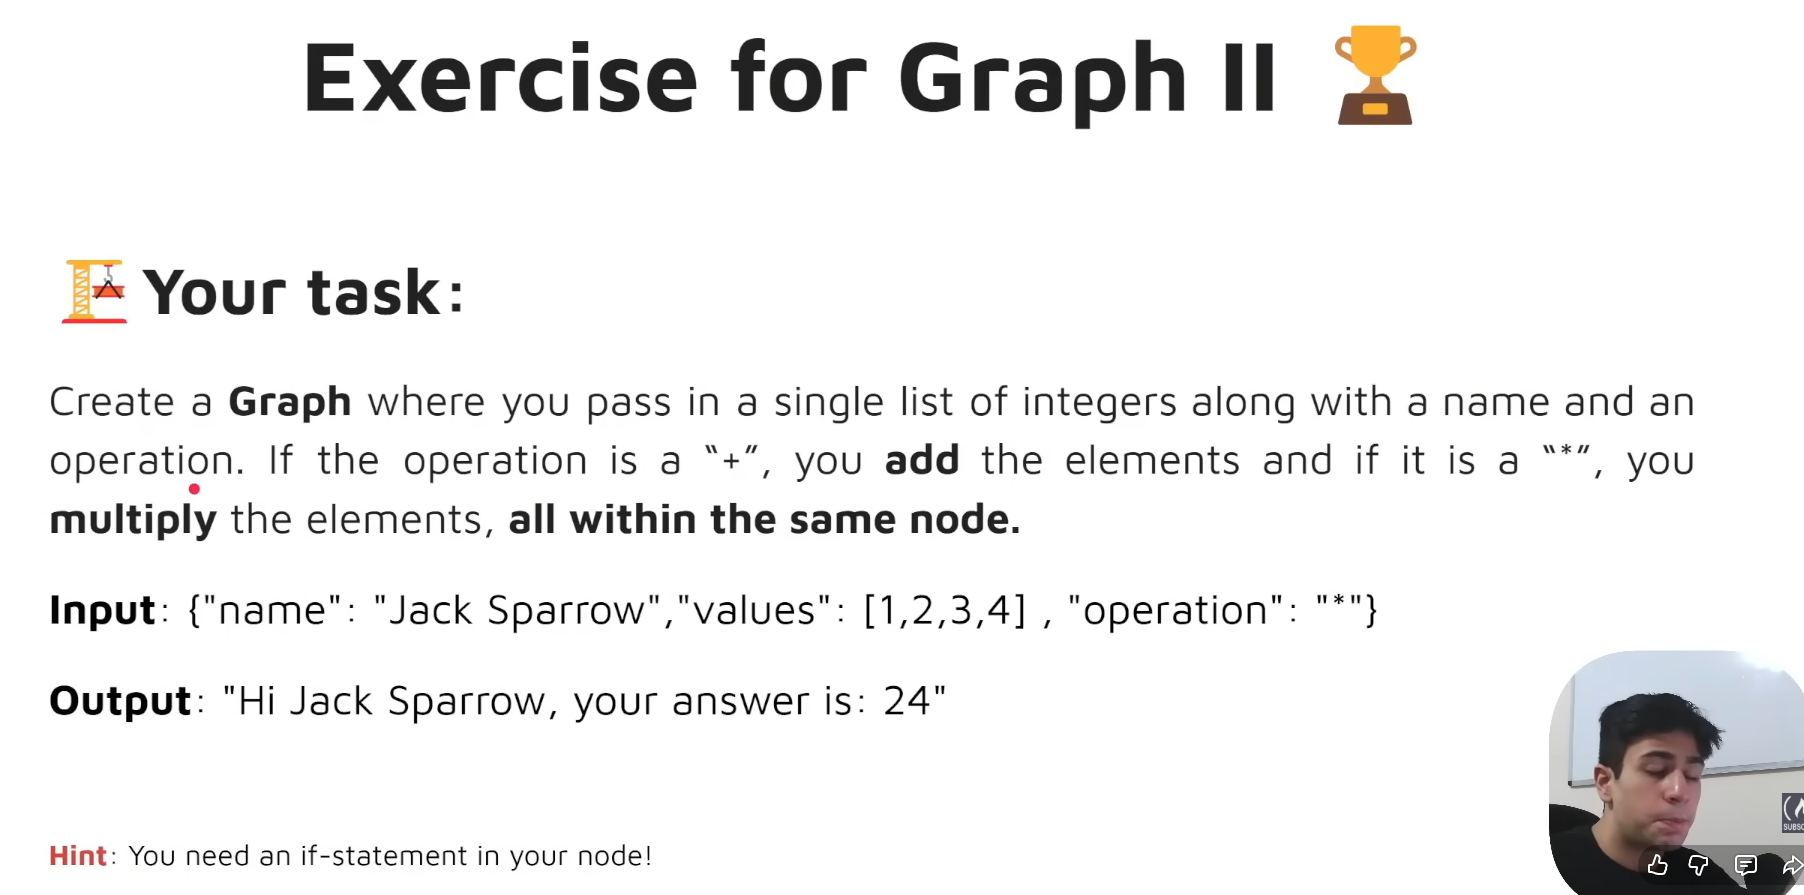

---

In [22]:
class AgentState2(TypedDict):
    values: List[int]
    operator: str
    name: str 
    result: str

In [23]:
import math
def process_values(state: AgentState2) -> AgentState2:
    """
    This function handles multiple different input
    """
    print(state)
    if state["operator"] == "+":
        state["result"] = f"Hi there {state['name']}! Your operation is = {sum(state['values'])}"
    elif state["operator"] == "*":
        state["result"] = f"Hi there {state['name']}! Your operation is = {math.prod((state['values']))}"  
    print(state)
    return state 

In [24]:
graph_2 = StateGraph(AgentState2)

graph_2.add_node("exercise2", process_values)
graph_2.set_entry_point("exercise2")
graph_2.set_finish_point("exercise2")

app = graph_2.compile()


In [25]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve", "operator": "*"})

{'values': [1, 2, 3, 4], 'operator': '*', 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'operator': '*', 'name': 'Steve', 'result': 'Hi there Steve! Your operation is = 24'}


In [26]:
print(answers)

{'values': [1, 2, 3, 4], 'operator': '*', 'name': 'Steve', 'result': 'Hi there Steve! Your operation is = 24'}
